In [1]:
library(Seurat)
library(ggplot2)
library(dplyr)
library(harmony)

Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.4.3”
Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: Rcpp



In [2]:
# load data
merged_VLP39_filtered <- readRDS("/QRISdata/Q4793/Yibi/merged_VLP39_filtered.rds")

In [4]:
# 1. Update metadata using case_match and filter out unmapped spots
merged_VLP39_filtered@meta.data <- merged_VLP39_filtered@meta.data %>%
  mutate(sample_id_p = case_match(tissues,
    "B2"    ~ "R1",
    "A2"    ~ "R2",
    "C1" ~ "R3_A",
    "C2" ~ "R3_B",
    "D2"    ~ "R4",
    "A1"    ~ "NR1",
    "C4"    ~ "NR2",
    "A3"    ~ "NR3",
    "B1"    ~ "NR4",
    "C3"    ~ "NR5",
    "D1"    ~ "NR6",
    .default = NA_character_  # Everything else becomes NA
  ))

# 2. Subset the Seurat object to remove rows where sample_id_p is NA
merged_VLP39_filtered <- subset(merged_VLP39_filtered, subset = !is.na(sample_id_p))

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `sample_id_p = case_match(...)`.
Caused by warning:
! `case_match()` was deprecated in dplyr 1.2.0.
ℹ Please use `recode_values()` instead.”
Warning message:
“Removing 1 cells missing data for vars requested”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warnin

In [5]:
table(merged_VLP39_filtered$sample_id_p)


 NR1  NR2  NR3  NR4  NR5  NR6   R1   R2 R3_A R3_B   R4 
1125  880  931 1716  964 1637 1764 1505  742  766 1581 

In [8]:
table(merged_VLP39_filtered@meta.data$cell_type)


     benign_salivary_tissue                immune_cells 
                        113                         554 
              normal_mucosa                      stroma 
                        147                        2981 
stroma_TIL_tumour_interface                      tumour 
                        618                        8042 
              tumour_stroma     tumour-stroma_interface 
                        237                         919 

In [22]:
merged_VLP39_filtered

An object of class Seurat 
35115 features across 13611 samples within 2 assays 
Active assay: SCT (17172 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: Spatial
 2 dimensional reductions calculated: pca, integrated.dr
 4 spatial fields of view present: slice1 slice1.2 slice1.3 slice1.4

In [17]:
# -----------------------------------------------------------------------------
# REQUIRED LIBRARIES
# -----------------------------------------------------------------------------
library(Seurat)
library(dplyr)
library(tidyr)
library(ggplot2)
library(edgeR)

# -----------------------------------------------------------------------------
# STEP 1: Create the Pseudo-bulk Partitions (Direct Metadata Modification)
# -----------------------------------------------------------------------------
# Set seed for reproducible random partitioning
set.seed(123) 

# Extract metadata and protect the row names (barcodes)
new_meta <- merged_VLP39_filtered@meta.data
new_meta$barcode <- rownames(new_meta)

# Perform the grouping and partition assignments
new_meta <- new_meta %>%
  group_by(sample_id_p, cell_type) %>%
  mutate(
    # Assign partition 1 for NR1 and NR4; otherwise randomly assign 1, 2, or 3
    partition = if_else(
      sample_id_p %in% c("NR1", "NR4"),
      1,
      sample(rep(1:3, length.out = n()))
    ),
    # Create a unique ID for each pseudo-bulk sample (e.g., "R2_tumour_1")
    pseudo_id = paste(sample_id_p, cell_type, partition, sep = "_")
  ) %>%
  ungroup() %>%
  as.data.frame() # Convert back to standard data frame

# Restore the row names
rownames(new_meta) <- new_meta$barcode

# Directly overwrite the Seurat meta.data slot to avoid tibble errors
merged_VLP39_filtered@meta.data <- new_meta

# -----------------------------------------------------------------------------
# STEP 2: Aggregate Counts 
# -----------------------------------------------------------------------------
# Aggregate raw counts across spots for each pseudo_id
# Note: Ensure the assay is set to your raw counts assay (usually "Spatial" or "RNA")
aggregated_data <- AggregateExpression(
  merged_VLP39_filtered, 
  group.by = "pseudo_id",
  assays = "Spatial", 
  slot = "counts", 
  return.seurat = FALSE
)

# Extract the count matrix from the list
pseudo_counts <- aggregated_data$Spatial

# -----------------------------------------------------------------------------
# STEP 3: Normalize using edgeR
# -----------------------------------------------------------------------------
# Create DGEList object
y <- DGEList(counts = pseudo_counts)

# Calculate normalization factors (Trimmed Mean of M-values)
y <- calcNormFactors(y, method = "TMM")

# Get log2 Counts Per Million (logCPM) for plotting
# prior.count = 2 shrinks extreme fold-changes for zero/low counts
logCPM <- cpm(y, log = TRUE, prior.count = 2)


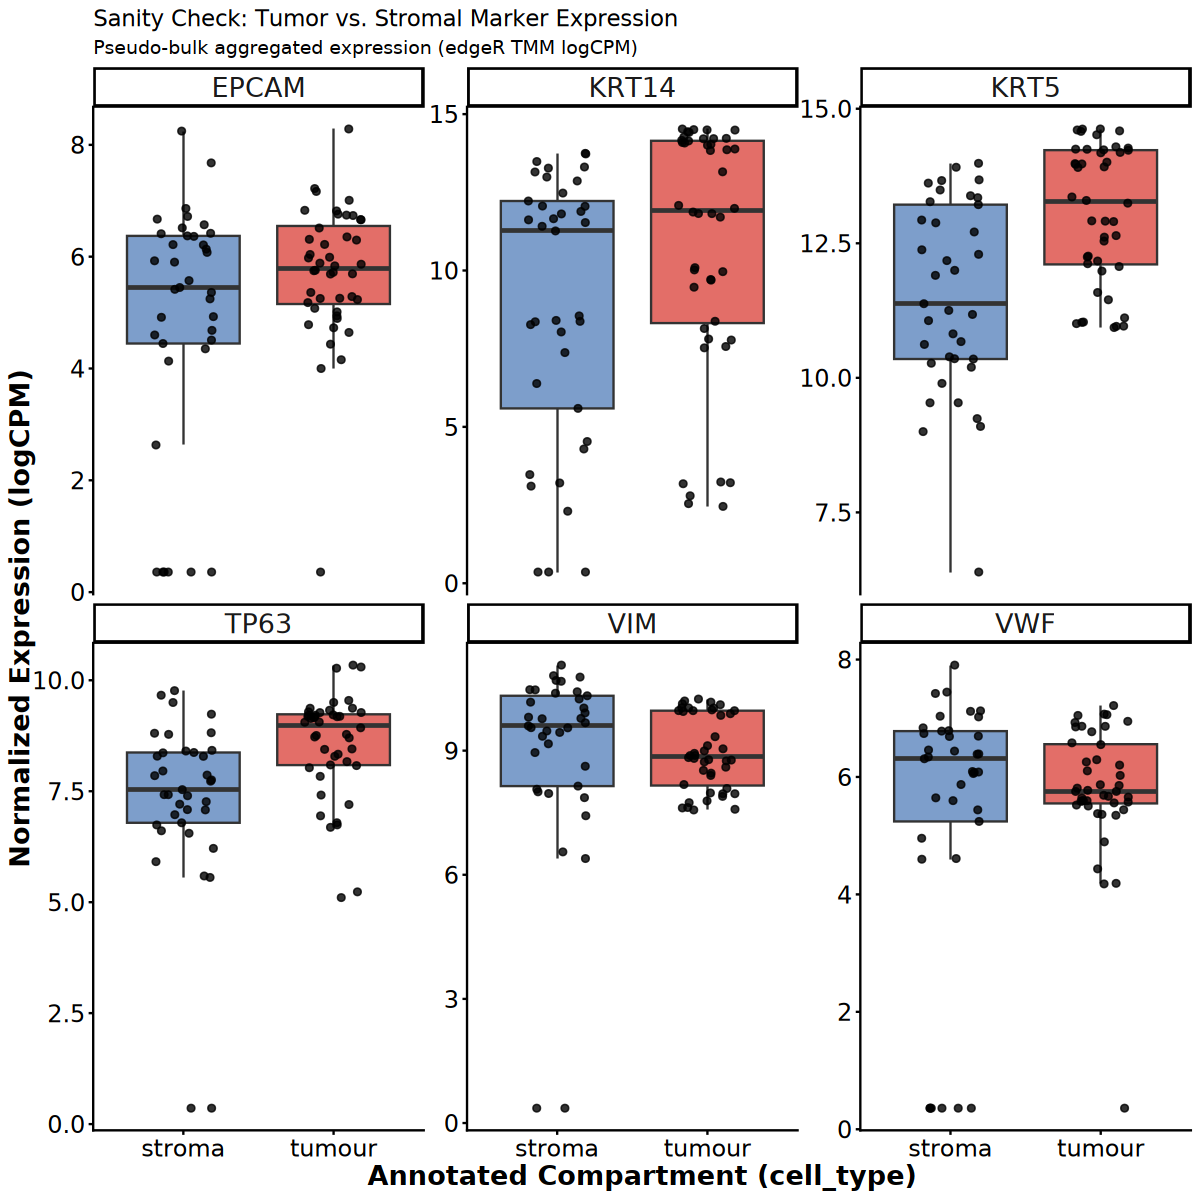

In [39]:
# -----------------------------------------------------------------------------
# STEP 4: Prepare Data for ggplot2 (BYPASSING MERGE ERROR)
# -----------------------------------------------------------------------------
marker_genes <- c("KRT5", "KRT14", "TP63", "EPCAM", "VIM", "VWF")
marker_genes <- intersect(marker_genes, rownames(logCPM))

# Extract expression data and transpose
plot_data <- as.data.frame(t(logCPM[marker_genes, , drop = FALSE]))
plot_data$pseudo_id <- rownames(plot_data)

# Bulletproof fix: Extract the cell_type directly from the Seurat-altered column name
# This ignores any hyphens or dots Seurat might have swapped in
plot_data$cell_type <- ifelse(
  grepl("tumour", plot_data$pseudo_id, ignore.case = TRUE), 
  "tumour", 
  "stroma"
)

# Pivot data to "long" format for ggplot faceting
plot_data_long <- plot_data %>%
  pivot_longer(
    cols = all_of(marker_genes), 
    names_to = "Gene", 
    values_to = "logCPM"
  )

# -----------------------------------------------------------------------------
# STEP 5: Generate Boxplots
# -----------------------------------------------------------------------------
options(repr.plot.width = 10, repr.plot.height = 10)
sanity_check_plot <- ggplot(plot_data_long, aes(x = cell_type, y = logCPM, fill = cell_type)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +
  geom_jitter(width = 0.2, size = 1.5, alpha = 0.8, color = "black") +
  facet_wrap(~ Gene, scales = "free_y", ncol = 3) +
  theme_classic() +
  labs(
    title = "Sanity Check: Tumor vs. Stromal Marker Expression",
    subtitle = "Pseudo-bulk aggregated expression (edgeR TMM logCPM)",
    x = "Annotated Compartment (cell_type)",
    y = "Normalized Expression (logCPM)"
  ) +
  scale_fill_manual(values = c("tumour" = "#d73027", "stroma" = "#4575b4")) +
  theme(
    strip.text = element_text(size = 16, face = "bold.italic"),
    axis.text.x = element_text(size = 14, color = "black"),
    axis.text.y = element_text(size = 14, color = "black"),
    axis.title = element_text(size = 16, face = "bold"),
    legend.position = "none" 
  )

print(sanity_check_plot)

In [25]:
deg <- read.csv("/QRISdata/Q4793/results/gene_list/recurrence_tumour_DE_genes_full.csv")

In [32]:
head(deg)

,genes,logFC,logCPM,F,PValue
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,NOC2L,1.2451165,5.798938,20.5766951,8.578012e-05
2,KLHL17,1.4376648,3.406204,10.7020928,2.689362e-03
3,PLEKHN1,0.8005187,5.029924,10.8214656,2.565067e-03
4,HES4,0.1613211,7.277037,0.3579484,5.541320e-01
5,ISG15,-0.8112238,9.510053,1.2744885,2.690240e-01
6,AGRN,0.4317238,7.862393,3.3126247,7.872643e-02


In [37]:
DEG_list <-deg %>% arrange(-logFC) %>% filter(PValue<0.05) %>% filter(abs(logFC)>1.5)